In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# TabM用
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

In [2]:
# データ読み込み（raw）
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

print('Train:', train.shape)
print('X:', X.shape, 'y:', y.shape)
print('Target mean:', float(y.mean()))

Train: (700000, 26)
X: (700000, 24) y: (700000,)
Target mean: 0.6232957142857143


In [3]:
# CV前提でシンプル比較（これまでの流れに合わせる）
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Categorical cols:', cat_cols)
print('Numeric cols:', len(num_cols))
print('CV:', cv)

Categorical cols: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
Numeric cols: 18
CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [4]:
def cv_eval_model(name, model, X, y, cv):
    scoring = {
        'auc': 'roc_auc',
        'acc': 'accuracy',
    }
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    return {
        'model': name,
        'auc_mean': float(np.mean(scores['test_auc'])),
        'auc_std': float(np.std(scores['test_auc'])),
        'acc_mean': float(np.mean(scores['test_acc'])),
        'acc_std': float(np.std(scores['test_acc'])),
    }

In [5]:
# XGBoost / LightGBM 用：最小限のOrdinal Encoding（raw特徴を壊さないため）
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
 )

# これまでの流れに合わせて「最小限」：主にrandom_stateだけ固定（比較の再現性）
xgb = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        random_state=42,
        n_estimators=281,
        max_depth=6,
        learning_rate=0.05,
        eval_metric='logloss',
    )),
 ])

lgbm = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LGBMClassifier(
        random_state=42,
    )),
 ])

results = []
results.append(cv_eval_model('xgboost', xgb, X, y, cv))
results.append(cv_eval_model('lightgbm', lgbm, X, y, cv))

pd.DataFrame(results).sort_values('auc_mean', ascending=False)

,model,auc_mean,auc_std,acc_mean,acc_std
1,lightgbm,0.722038,0.000867,0.68070,0.000976
0,xgboost,0.721864,0.000898,0.68093,0.001039


In [6]:
# CatBoost（カテゴリ列をrawで扱える）

from catboost import CatBoostClassifier

def cv_eval_catboost(X, y, cat_cols, cv):
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]
    aucs = []
    accs = []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = CatBoostClassifier(
            iterations=300,
            depth=5,
            learning_rate=0.1,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=42,
            verbose=False,
        )
        model.fit(X_tr, y_tr, cat_features=cat_idx)
        proba = model.predict_proba(X_va)[:, 1]
        pred = (proba >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_va, proba))
        accs.append(accuracy_score(y_va, pred))

    return {
        'model': 'catboost',
        'auc_mean': float(np.mean(aucs)),
        'auc_std': float(np.std(aucs)),
        'acc_mean': float(np.mean(accs)),
        'acc_std': float(np.std(accs)),
    }

#results.append(cv_eval_catboost(X, y, cat_cols, cv))
pd.DataFrame(results).sort_values('auc_mean', ascending=False)

,model,auc_mean,auc_std,acc_mean,acc_std
1,lightgbm,0.722038,0.000867,0.68070,0.000976
0,xgboost,0.721864,0.000898,0.68093,0.001039


## 次（アンサンブル）

このノートで上位モデルが決まったら、
- 予測確率の単純平均（soft-vote）
- 重み付き平均
をまず1セルで試します。

## OOF予測の相関確認

モデルの予測の多様性を確認するため、OOF（Out-of-Fold）予測を作成して相関を見る。
- 相関が高い（0.95以上）→ アンサンブル効果薄い
- 相関が低い（0.85未満）→ アンサンブル効果期待大

In [7]:
# OOF予測を作成（LightGBM）
def get_oof_predictions_lgbm(X, y, cv, cat_cols):
    oof_preds = np.zeros(len(X))
    
    preprocess = ColumnTransformer(
        transformers=[
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )
    
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        # 前処理
        X_tr_transformed = preprocess.fit_transform(X_tr)
        X_va_transformed = preprocess.transform(X_va)
        
        model = LGBMClassifier(random_state=42, verbose=-1)
        model.fit(X_tr_transformed, y_tr)
        oof_preds[va_idx] = model.predict_proba(X_va_transformed)[:, 1]
        
    return oof_preds

oof_lgbm = get_oof_predictions_lgbm(X, y, cv, cat_cols)
print(f'LGBM OOF AUC: {roc_auc_score(y, oof_lgbm):.5f}')

c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

LGBM OOF AUC: 0.72203


In [8]:
# OOF予測を作成（XGBoost）
def get_oof_predictions_xgb(X, y, cv, cat_cols):
    oof_preds = np.zeros(len(X))
    
    preprocess = ColumnTransformer(
        transformers=[
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )
    
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        # 前処理
        X_tr_transformed = preprocess.fit_transform(X_tr)
        X_va_transformed = preprocess.transform(X_va)
        
        model = XGBClassifier(
            random_state=42,
            n_estimators=281,
            max_depth=6,
            learning_rate=0.05,
            eval_metric='logloss',
            verbosity=0,
        )
        model.fit(X_tr_transformed, y_tr)
        oof_preds[va_idx] = model.predict_proba(X_va_transformed)[:, 1]
        
    return oof_preds

oof_xgb = get_oof_predictions_xgb(X, y, cv, cat_cols)
print(f'XGB OOF AUC: {roc_auc_score(y, oof_xgb):.5f}')

XGB OOF AUC: 0.72186


In [9]:
# OOF予測を作成（CatBoost）
def get_oof_predictions_catboost(X, y, cv, cat_cols):
    oof_preds = np.zeros(len(X))
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]
    
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        model = CatBoostClassifier(
            iterations=300,
            depth=5,
            learning_rate=0.1,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=42,
            verbose=False,
            allow_writing_files=False,  # ファイル書き込みを無効化してUnicodeエラーを回避
        )
        model.fit(X_tr, y_tr, cat_features=cat_idx)
        oof_preds[va_idx] = model.predict_proba(X_va)[:, 1]
        
    return oof_preds

oof_catboost = get_oof_predictions_catboost(X, y, cv, cat_cols)
print(f'CatBoost OOF AUC: {roc_auc_score(y, oof_catboost):.5f}')

CatBoost OOF AUC: 0.72092


In [10]:
# TabMモデルの実装（シンプルなMLP with Batch Normalization）
class TabMModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super(TabMModel, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class TabMClassifier:
    def __init__(self, hidden_dims=[128, 64, 32], dropout=0.3, epochs=50, 
                 batch_size=256, lr=0.001, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = device
        self.model = None
        
    def fit(self, X, y):
        input_dim = X.shape[1]
        self.model = TabMModel(input_dim, self.hidden_dims, self.dropout).to(self.device)
        
        criterion = nn.BCELoss()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-5)
        
        X_tensor = torch.FloatTensor(X).to(self.device)
        y_tensor = torch.FloatTensor(y).unsqueeze(1).to(self.device)
        
        dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        
        return self
    
    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        
        with torch.no_grad():
            proba = self.model(X_tensor).cpu().numpy().flatten()
        
        return np.column_stack([1 - proba, proba])
    
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

print('TabMモデルのクラスを定義しました')

TabMモデルのクラスを定義しました


In [11]:
# OOF予測を作成（TabM）
def get_oof_predictions_tabm(X, y, cv, cat_cols):
    oof_preds = np.zeros(len(X))
    
    # TabM用の前処理：すべての特徴量を数値化してスケーリング
    le_dict = {}
    X_processed = X.copy()
    
    # カテゴリ列をLabel Encoding
    for col in cat_cols:
        le = LabelEncoder()
        X_processed[col] = le.fit_transform(X_processed[col])
        le_dict[col] = le
    
    scaler = StandardScaler()
    
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_processed, y)):
        print(f'TabM Fold {fold + 1}/{cv.get_n_splits()}')
        
        X_tr, X_va = X_processed.iloc[tr_idx], X_processed.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        # スケーリング
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_va_scaled = scaler.transform(X_va)
        
        # モデル学習
        model = TabMClassifier(
            hidden_dims=[128, 64, 32],
            dropout=0.3,
            epochs=50,
            batch_size=256,
            lr=0.001
        )
        model.fit(X_tr_scaled, y_tr.values)
        oof_preds[va_idx] = model.predict_proba(X_va_scaled)[:, 1]
    
    return oof_preds

oof_tabm = get_oof_predictions_tabm(X, y, cv, cat_cols)
print(f'\nTabM OOF AUC: {roc_auc_score(y, oof_tabm):.5f}')

TabM Fold 1/5
TabM Fold 2/5
TabM Fold 3/5
TabM Fold 4/5
TabM Fold 5/5

TabM OOF AUC: 0.69590


In [12]:
# OOF予測の相関行列を確認
import matplotlib.pyplot as plt
import seaborn as sns

oof_df = pd.DataFrame({
    'LGBM': oof_lgbm,
    'XGB': oof_xgb,
    'CatBoost': oof_catboost,
    'TabM': oof_tabm,
})
oof_df

,LGBM,XGB,CatBoost,TabM
0,0.510893,0.505649,0.492059,0.593682
1,0.596496,0.589325,0.591661,0.572394
2,0.250803,0.244613,0.262400,0.267196
3,0.543574,0.561105,0.558530,0.612487
4,0.762958,0.771660,0.713786,0.709771
...,...,...,...,...
699995,0.401103,0.375743,0.372396,0.416145
699996,0.604422,0.599582,0.599784,0.606543
699997,0.648085,0.640598,0.650489,0.589838
699998,0.604609,0.621305,0.614833,0.601379


OOF予測の相関行列:
              LGBM       XGB  CatBoost      TabM
LGBM      1.000000  0.990800  0.989552  0.929743
XGB       0.990800  1.000000  0.989109  0.932996
CatBoost  0.989552  0.989109  1.000000  0.940382
TabM      0.929743  0.932996  0.940382  1.000000



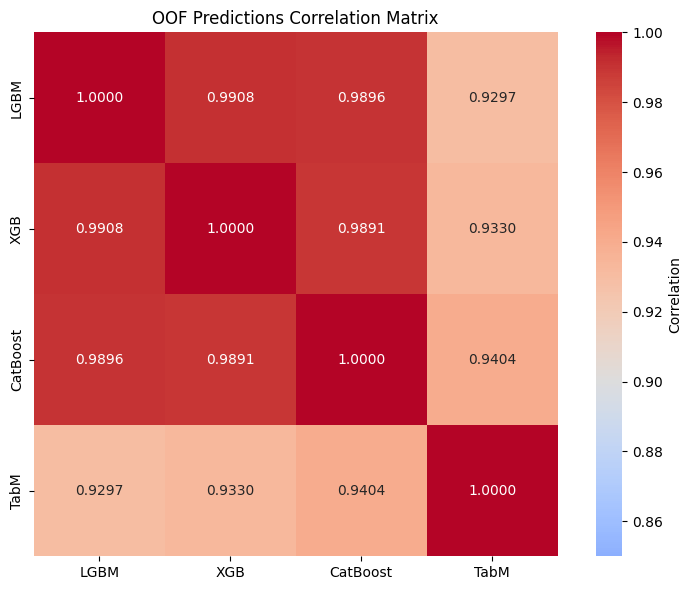

平均相関: 0.9621

判定:
  → 相関が非常に高い（0.95+）: アンサンブル効果は限定的


In [13]:

# 相関行列
corr_matrix = oof_df.corr()
print("OOF予測の相関行列:")
print(corr_matrix)
print()

# ヒートマップで可視化
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm', center=0.9, 
            vmin=0.85, vmax=1.0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('OOF Predictions Correlation Matrix')
plt.tight_layout()
plt.show()

# 平均相関を計算（対角線を除く）
avg_corr = (corr_matrix.values.sum() - 4) / 12  # 4x4行列で対角線4つを除く
print(f'平均相関: {avg_corr:.4f}')
print()
print('判定:')
if avg_corr >= 0.95:
    print('  → 相関が非常に高い（0.95+）: アンサンブル効果は限定的')
elif avg_corr >= 0.90:
    print('  → 相関が高い（0.90-0.95）: 単純ブレンドで若干改善の余地あり')
elif avg_corr >= 0.85:
    print('  → 相関が中程度（0.85-0.90）: ブレンドで改善期待、スタッキングも検討')
else:
    print('  → 相関が低い（0.85未満）: アンサンブル効果大、スタッキング推奨')

In [14]:
# エラー（誤差）の相関も確認
# 各モデルがどの部分で間違えるかが異なれば、アンサンブルで補完し合える

errors_df = pd.DataFrame({
    'LGBM_error': np.abs(y - oof_lgbm),
    'XGB_error': np.abs(y - oof_xgb),
    'CatBoost_error': np.abs(y - oof_catboost),
    'TabM_error': np.abs(y - oof_tabm),
})
errors_df

,LGBM_error,XGB_error,CatBoost_error,TabM_error
0,0.489107,0.494351,0.507941,0.406318
1,0.403504,0.410675,0.408339,0.427606
2,0.250803,0.244613,0.262400,0.267196
3,0.456426,0.438895,0.441470,0.387513
4,0.237042,0.228340,0.286214,0.290229
...,...,...,...,...
699995,0.401103,0.375743,0.372396,0.416145
699996,0.395578,0.400418,0.400216,0.393457
699997,0.351915,0.359402,0.349511,0.410162
699998,0.395391,0.378695,0.385167,0.398621


エラー（誤差）の相関行列:
                LGBM_error  XGB_error  CatBoost_error  TabM_error
LGBM_error        1.000000   0.992452        0.991443    0.944711
XGB_error         0.992452   1.000000        0.991100    0.947387
CatBoost_error    0.991443   0.991100        1.000000    0.953438
TabM_error        0.944711   0.947387        0.953438    1.000000



C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 12411 (\N{HIRAGANA LETTER HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\3923961843.py:11: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing fr

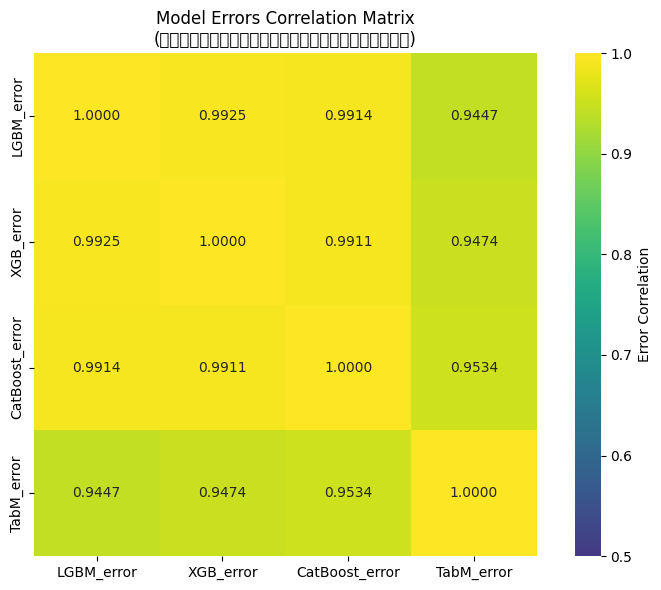

エラー平均相関: 0.9701
→ エラー相関が低いほど、モデルが異なるサンプルで間違えるため補完効果が高い


In [15]:

error_corr = errors_df.corr()
print("エラー（誤差）の相関行列:")
print(error_corr)
print()

# ヒートマップで可視化
plt.figure(figsize=(8, 6))
sns.heatmap(error_corr, annot=True, fmt='.4f', cmap='viridis', center=0.7,
            vmin=0.5, vmax=1.0, square=True, cbar_kws={'label': 'Error Correlation'})
plt.title('Model Errors Correlation Matrix\n(低いほどモデルが異なる部分で間違える＝補完性が高い)')
plt.tight_layout()
plt.show()

avg_error_corr = (error_corr.values.sum() - 4) / 12  # 4x4行列で対角線4つを除く
print(f'エラー平均相関: {avg_error_corr:.4f}')
print('→ エラー相関が低いほど、モデルが異なるサンプルで間違えるため補完効果が高い')

## LightGBM ベイズ最適化（Optuna）

相関がほぼ1だったため、アンサンブルは効果薄い。
→ 単一モデル（LGBM）のパラメータ最適化に注力

In [16]:
import optuna
from optuna.samplers import TPESampler

# Optunaの目的関数
def objective(trial):
    # パラメータ探索空間
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1,
    }
    
    # 前処理
    preprocess = ColumnTransformer(
        transformers=[
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    )
    
    # CV で評価
    auc_scores = []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        # 前処理
        X_tr_transformed = preprocess.fit_transform(X_tr)
        X_va_transformed = preprocess.transform(X_va)
        
        # モデル学習
        model = LGBMClassifier(**params)
        model.fit(X_tr_transformed, y_tr)
        
        # 予測
        y_pred = model.predict_proba(X_va_transformed)[:, 1]
        auc = roc_auc_score(y_va, y_pred)
        auc_scores.append(auc)
    
    return np.mean(auc_scores)

print('Optunaによるハイパーパラメータ最適化を開始...')

Optunaによるハイパーパラメータ最適化を開始...


In [17]:
# 最適化実行
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='lgbm_optimization'
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print('\n最適化完了!')
print(f'Best AUC: {study.best_value:.5f}')
print(f'\nBest Parameters:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

[I 2026-01-01 18:17:01,351] A new study created in memory with name: lgbm_optimization


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

[I 2026-01-01 18:17:17,224] Trial 0 finished with value: 0.7263206578015587 and parameters: {'n_estimators': 218, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 98, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.7263206578015587.


c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

...

c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

[I 2026-01-02 15:52:41,897] Trial 18 finished with value: 0.7168930249047994 and parameters: {'n_estimators': 389, 'max_depth': 4, 'learning_rate': 0.036046969689776935, 'num_leaves': 20, 'min_child_samples': 68, 'subsample': 0.8135233208242552, 'colsample_bytree': 0.8264423346529436, 'reg_alpha': 6.479872737032084e-08, 'reg_lambda': 4.181087639543297e-08}. Best is trial 12 with value: 0.7279492990721834.


c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[W 2026-01-02 15:52:51,238] Trial 19 failed with parameters: {'n_estimators': 467, 'max_depth': 5, 'learning_rate': 0.14546797732184336, 'num_leaves': 115, 'min_child_samples': 94, 'subsample': 0.7231610042250181, 'colsample_bytree': 0.5471288688885415, 'reg_alpha': 5.799449092292779e-05, 'reg_lambda': 1.549531910614886e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\mikku\AppData\Local\Temp\ipykernel_45820\600083979.py", line 38, in objective
    X_va_transformed = preprocess.transform(X_va)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
         

KeyboardInterrupt: 

In [ ]:
# 最適化の過程を可視化
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

# パラメータの重要度
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [ ]:
# 最適化されたパラメータで最終モデルを訓練してテストデータに予測
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['verbose'] = -1

# 前処理
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

# 全データで学習
X_transformed = preprocess.fit_transform(X)
X_test = test.drop(['id'], axis=1)
X_test_transformed = preprocess.transform(X_test)

final_model = LGBMClassifier(**best_params)
final_model.fit(X_transformed, y)

# テストデータに予測
test_preds = final_model.predict_proba(X_test_transformed)[:, 1]

# サブミッションファイル作成
submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_preds
})

submission.to_csv('submission_lgbm_optimized.csv', index=False)
print('✅ submission_lgbm_optimized.csv を保存しました')
print(f'Best CV AUC: {study.best_value:.5f}')

c:\Users\mikku\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



✅ submission_lgbm_optimized.csv を保存しました
Best CV AUC: 0.72822


### 補足: 木の深さを変えたアンサンブルについて

**推奨しない理由:**
- 同じLGBMアルゴリズムで深さだけ変えても、予測の相関は依然として高い（0.95+）
- 計算コストが増えるが、スコア改善は0.001未満の微増程度
- オーバーフィッティングのリスクが増加

**より効果的な代替案:**
1. ✅ **パラメータ最適化**（上記実装済み）- 単一モデルの性能を最大化
2. **特徴量エンジニアリング** - 多項式特徴、交互作用項、集約統計量など
3. **異なるアルゴリズム** - もし多様性が必要なら、NN（TabNet/MLP）やCatBoost強化を検討